# 2D Acoustic Full Waveform Inversion — Scratch Implementation

This notebook walks through a scratch implementation of 2D acoustic FWI on the Marmousi model.
Unlike the companion `seismic_FWI` task (which delegates to the `deepwave` library), **every component
here is implemented from scratch in pure PyTorch**: the Ricker wavelet, the Convolutional PML absorbing
boundary conditions, the 4th-order finite-difference time-domain (FDTD) wave propagator, and
the FWI optimisation loop.

All heavy computation has been prerun.  This notebook loads the saved results and runs in seconds.

## 1. Problem Setup

We want to recover the subsurface P-wave velocity field $v(y, x)$ from surface seismograms.
The inverse problem minimises the waveform misfit:

$$J(v) = \tfrac{1}{2}\sum_s \bigl\|\mathcal{T}[F_s(v)] - \mathcal{T}[d_s^{\text{obs}}]\bigr\|_2^2$$

where $F_s(v)$ is the acoustic forward model for shot $s$, $d_s^{\text{obs}}$ is the observed seismogram,
and $\mathcal{T}$ is a 5-sample cosine taper.

### Dataset: Marmousi model

| Parameter | Value |
|-----------|-------|
| Grid size | 461 × 151 cells at 20 m spacing |
| P-wave velocity range | ~1500 – 5500 m/s |
| Number of shots | 10 (uniform surface coverage) |
| Receivers per shot | 93 (uniform surface coverage) |
| Time samples | 1350 at Δt = 4 ms (5.4 s total) |
| Source wavelet | Ricker, 5 Hz central frequency |

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..'))  # seismic_FWI_original root

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load data
data = np.load('../data/raw_data.npz')
v_true   = data['v_true']    # (461, 151) ground truth
v_init   = data['v_init']    # (461, 151) smoothed initial model
obs_data = data['observed_data']  # (10, 93, 1350)
dx = float(data['dx'])       # 20 m
dt = float(data['dt'])       # 4 ms
freq = float(data['freq'])   # 5 Hz
ny, nx = v_true.shape
print(f'Model: {ny}×{nx}, dx={dx}m, dt={dt}s, freq={freq}Hz')
print(f'Velocity range: {v_true.min():.0f} – {v_true.max():.0f} m/s')

Model: 461×151, dx=20.0m, dt=0.004s, freq=5.0Hz
Velocity range: 1504 – 5500 m/s


## 2. Forward Model: 2D Acoustic Wave Equation

The acoustic wave equation in 2D is:

$$\frac{\partial^2 p}{\partial t^2} = v^2(\mathbf{x})\left(\frac{\partial^2 p}{\partial y^2} + \frac{\partial^2 p}{\partial x^2}\right) + v^2(\mathbf{x})\,s(t)\,\delta(\mathbf{x} - \mathbf{x}_s)$$

### Time integration: Verlet / Leap-frog

$$p^{n+1} = v^2\,\Delta t^2\,\mathcal{L}(p^n,\psi^n,\zeta^n) + 2p^n - p^{n-1}$$

where $\mathcal{L}$ is the PML-modified Laplacian (see Section 3).

### Space derivatives: 4th-order FD stencils

$$\frac{\partial^2 p}{\partial x^2}\bigg|_i \approx \frac{-\tfrac{5}{2}p_i + \tfrac{4}{3}(p_{i+1}+p_{i-1}) - \tfrac{1}{12}(p_{i+2}+p_{i-2})}{\Delta x^2}$$

### CFL stability condition

$$\Delta t_{\text{inner}} \leq \frac{0.6}{\sqrt{1/\Delta y^2 + 1/\Delta x^2}\cdot v_{\max}}$$

The user time step $\Delta t$ is subdivided: `step_ratio = ceil(dt / dt_max)`,
$\Delta t_{\text{inner}} = \Delta t / \text{step\_ratio}$.

In [3]:
from src.physics_model import (
    make_ricker_wavelet, make_acquisition_geometry,
    cfl_step_ratio, forward_model
)

# CFL condition for the Marmousi model
v_max = float(v_true.max())
inner_dt, step_ratio = cfl_step_ratio(dx, dx, dt, v_max)
print(f'v_max = {v_max:.0f} m/s')
print(f'step_ratio = {step_ratio}  (inner_dt = {inner_dt*1e3:.4f} ms)')
print(f'nt_inner = {1350 * step_ratio} time steps per shot')

v_max = 5500 m/s
step_ratio = 3  (inner_dt = 1.3333 ms)
nt_inner = 4050 time steps per shot


## 3. Absorbing Boundaries: Convolutional PML

Reflections from the model boundaries create spurious arrivals.  We suppress them with a
**Convolutional PML (C-PML)** layer, following Pasalic & McGarry (2010).

### PML profile construction

For each dimension $d$ with PML width $L$ (metres):

$$\sigma_0 = -\frac{(1+p)\,v_{\max}\ln R}{2L}, \quad \alpha_0 = \pi f_{\text{pml}}$$

At each grid point, $\eta \in [0,1]$ = normalised distance into the PML:

$$\sigma = \sigma_0\,\eta^p, \quad \alpha = \alpha_0(1-\eta)$$

$$a = e^{-(\sigma+\alpha)\,\Delta t_{\text{inner}}}, \quad b = \frac{\sigma}{\sigma+\alpha}(a-1)$$

Interior points: $a=0$, $b=0$ (PML inactive).

### C-PML wave step

Auxiliary variables $\psi_d$, $\zeta_d$ per dimension evolve as:

$$\text{tmp}_d = (1+b_d)\frac{\partial^2 p}{\partial d^2} + \frac{\partial b_d}{\partial d}\frac{\partial p}{\partial d} + \frac{\partial}{\partial d}(a_d\psi_d)$$

$$\psi_d^{n+1} = b_d\frac{\partial p}{\partial d} + a_d\psi_d, \qquad \zeta_d^{n+1} = b_d\,\text{tmp}_d + a_d\zeta_d$$

The PML-modified Laplacian is:

$$\mathcal{L} = \sum_d \bigl[(1+b_d)\,\text{tmp}_d + a_d\,\zeta_d\bigr]$$

In the interior ($a=b=0$), $\mathcal{L}$ reduces to the standard Laplacian.

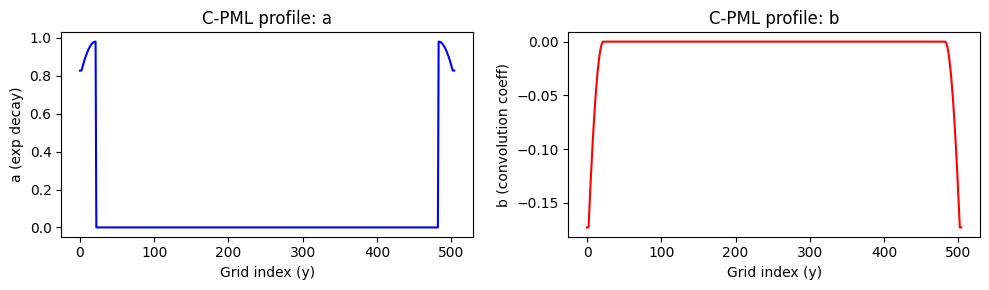

Padded model: 505 × 195 (pad=22 on each side)


In [4]:
from src.physics_model import setup_pml_profiles

# Visualise the PML a-profile for the y-dimension
pml_width, fd_pad = 20, 2
pad = pml_width + fd_pad
ny_p = ny + 2*pad

pml = setup_pml_profiles(
    ny_p, nx + 2*pad, pml_width, fd_pad,
    dx, dx, inner_dt, v_max,
    torch.float32, torch.device('cpu'), freq,
)
ay = pml[0].squeeze().numpy()  # exponential decay profile, y-direction
by = pml[1].squeeze().numpy()  # convolution coefficient, y-direction

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(ay, 'b-', lw=1.5)
axes[0].set_xlabel('Grid index (y)'); axes[0].set_ylabel('a (exp decay)'); axes[0].set_title('C-PML profile: a')
axes[1].plot(by, 'r-', lw=1.5)
axes[1].set_xlabel('Grid index (y)'); axes[1].set_ylabel('b (convolution coeff)'); axes[1].set_title('C-PML profile: b')
plt.tight_layout(); plt.show()
print(f'Padded model: {ny_p} × {nx+2*pad} (pad={pad} on each side)')

## 4. Source Wavelet: Ricker

$$s(t) = \bigl(1 - 2\pi^2 f^2(t-t_p)^2\bigr)\exp\bigl(-\pi^2 f^2(t-t_p)^2\bigr), \quad t_p = \tfrac{1.5}{f}$$

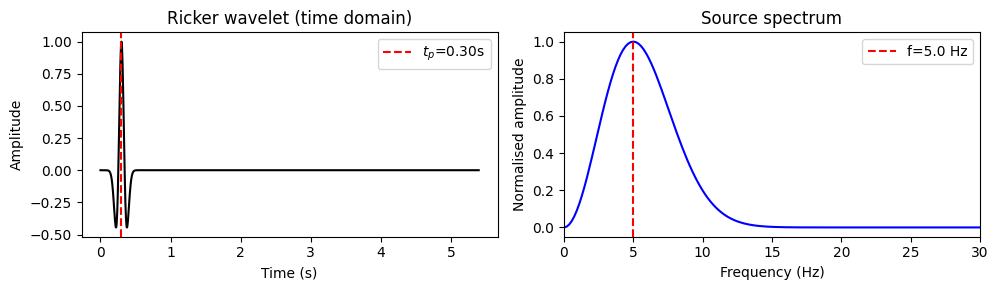

In [5]:
nt = obs_data.shape[2]
n_shots, n_rec = obs_data.shape[0], obs_data.shape[1]
src_amp = make_ricker_wavelet(freq, nt, dt, n_shots)

t = np.arange(nt) * dt
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(t, src_amp[0, 0].numpy(), 'k-', lw=1.5)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude'); axes[0].set_title('Ricker wavelet (time domain)')
axes[0].axvline(1.5/freq, color='r', ls='--', label=f'$t_p$={1.5/freq:.2f}s')
axes[0].legend()
# Frequency spectrum
S = np.abs(np.fft.rfft(src_amp[0, 0].numpy()))
freqs = np.fft.rfftfreq(nt, d=dt)
axes[1].plot(freqs, S/S.max(), 'b-', lw=1.5)
axes[1].axvline(freq, color='r', ls='--', label=f'f={freq} Hz')
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Normalised amplitude'); axes[1].set_title('Source spectrum')
axes[1].set_xlim(0, 30); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Observed Shot Gather

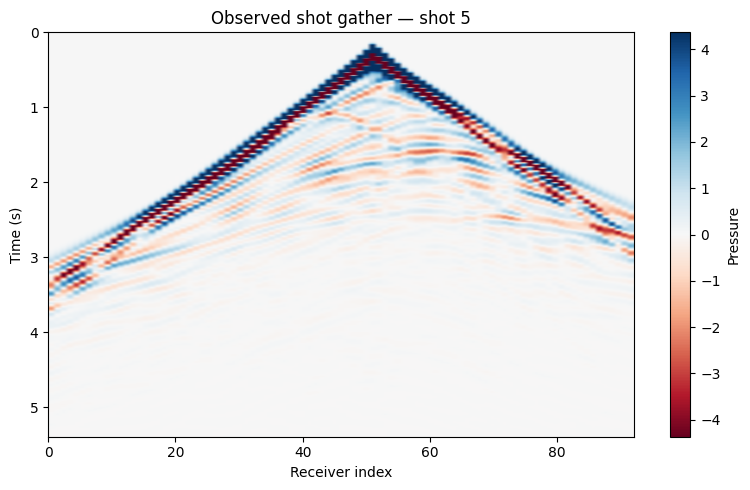

In [6]:
shot_idx = 5  # middle shot
gather = obs_data[shot_idx]  # (93, 1350)
clip = np.percentile(np.abs(gather), 98)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(gather.T, aspect='auto', cmap='RdBu', vmin=-clip, vmax=clip,
               extent=[0, n_rec-1, t[-1], 0])
ax.set_xlabel('Receiver index'); ax.set_ylabel('Time (s)')
ax.set_title(f'Observed shot gather — shot {shot_idx}')
plt.colorbar(im, ax=ax, label='Pressure')
plt.tight_layout(); plt.show()

## 6. Full Waveform Inversion

FWI minimises the waveform misfit by gradient descent.  The gradient

$$\nabla_v J = \frac{\partial J}{\partial v}$$

is computed by **backpropagation through the FDTD loop** using PyTorch autograd.

To keep GPU memory bounded, we use **gradient checkpointing** (every 64 inner steps):
instead of storing all wavefield states during the forward pass, only segment boundary
states are kept; intermediate activations are recomputed on the backward pass.

### Gradient post-processing (every iteration)

1. Gaussian smooth the gradient: $\sigma = 1$ grid point
2. Clip at the 98th percentile of $|\nabla J|$

### Optimiser

- Adam, lr = 100 m/s
- MultiStepLR: halve lr at epochs 75 and 300
- 200 epochs; velocity clamped to [1480, 5800] m/s after each update

### 6.1 Run FWI (precomputed)

Results are loaded from `evaluation/reference_outputs/`.

In [7]:
# Load precomputed results
v_inv   = np.load('../evaluation/reference_outputs/v_inv.npy')
losses  = np.load('../evaluation/reference_outputs/losses.npy')
pred_data = np.load('../evaluation/reference_outputs/pred_data.npy')

with open('../evaluation/reference_outputs/metrics.json') as f:
    metrics = json.load(f)

print(f'Epochs: {len(losses)}')
print(f'Final loss: {losses[-1]:.4e}')
print(f'Velocity rel. L2 error: {metrics["velocity_rel_l2"]*100:.2f}%')
print(f'Data rel. L2 error (mean): {metrics["data_rel_l2_mean"]*100:.2f}%')

Epochs: 200
Final loss: 1.4393e-03
Velocity rel. L2 error: 9.75%
Data rel. L2 error (mean): 1.69%


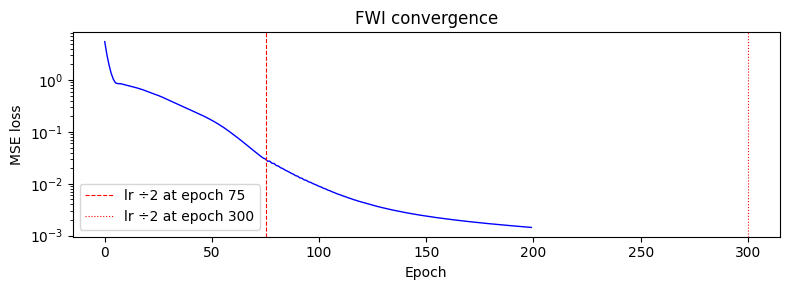

In [8]:
# Loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(losses, 'b-', lw=1)
ax.axvline(75,  color='r', ls='--', lw=0.8, label='lr ÷2 at epoch 75')
ax.axvline(300, color='r', ls=':',  lw=0.8, label='lr ÷2 at epoch 300')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss'); ax.set_title('FWI convergence')
ax.legend()
plt.tight_layout(); plt.show()

## 7. Velocity Model Comparison

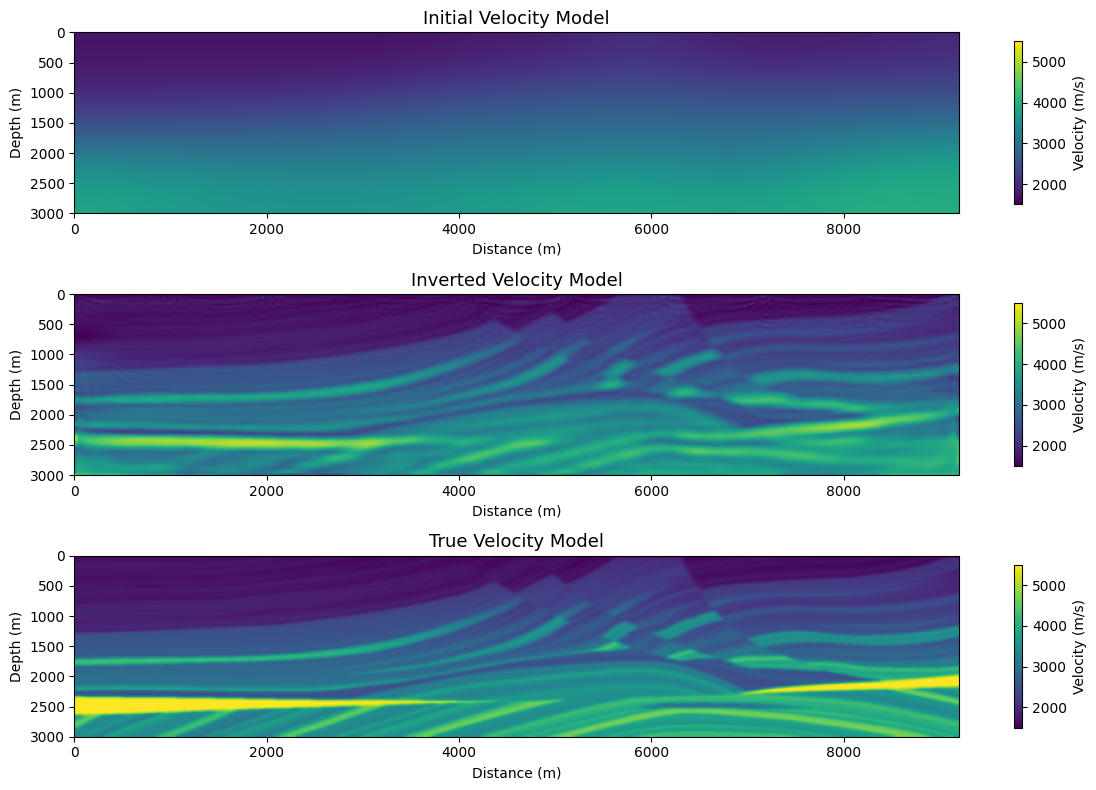

In [9]:
from src.visualization import plot_velocity_models
fig = plot_velocity_models(v_true, v_init, v_inv, dx, dx)
plt.show()

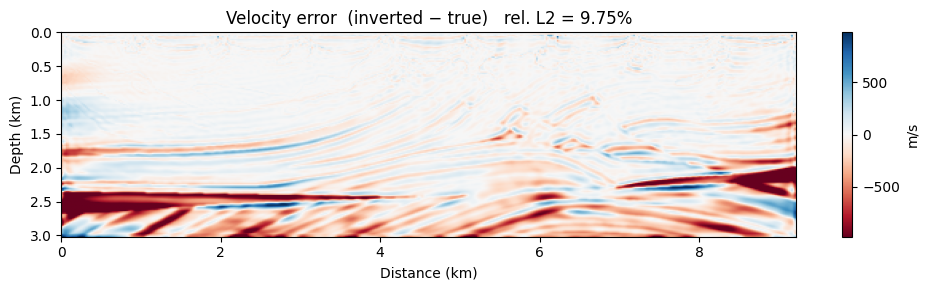

In [10]:
# Difference map
diff = v_inv - v_true
clip_v = np.percentile(np.abs(diff), 98)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(diff.T, aspect='auto', cmap='RdBu', vmin=-clip_v, vmax=clip_v,
               extent=[0, ny*dx/1000, nx*dx/1000, 0])
ax.set_xlabel('Distance (km)'); ax.set_ylabel('Depth (km)')
ax.set_title(f'Velocity error  (inverted − true)   rel. L2 = {metrics["velocity_rel_l2"]*100:.2f}%')
plt.colorbar(im, ax=ax, label='m/s')
plt.tight_layout(); plt.show()

## 8. Waveform Comparison

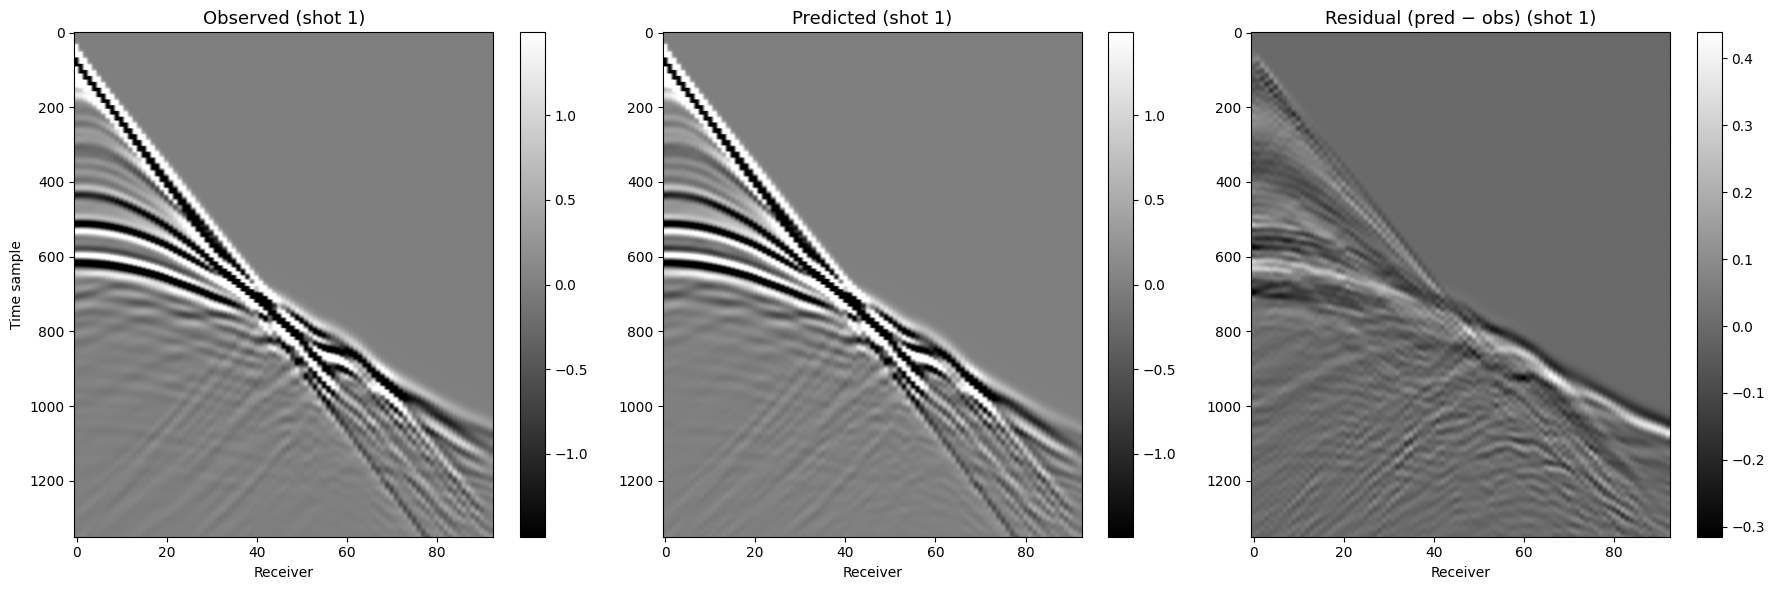

In [11]:
from src.visualization import plot_data_comparison
fig = plot_data_comparison(obs_data, pred_data, shot_idx=0)
plt.show()

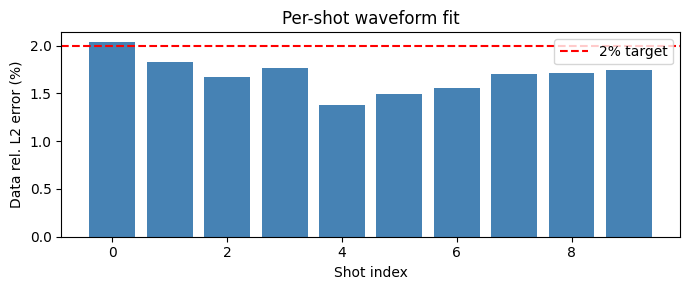

In [12]:
# Per-shot data relative L2 error
per_shot = metrics['data_rel_l2_per_shot']
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(n_shots), [r*100 for r in per_shot], color='steelblue')
ax.axhline(2.0, color='r', ls='--', label='2% target')
ax.set_xlabel('Shot index'); ax.set_ylabel('Data rel. L2 error (%)')
ax.set_title('Per-shot waveform fit')
ax.legend()
plt.tight_layout(); plt.show()

## 9. Implementation Correctness: Parity with deepwave

The forward model was validated against the `deepwave` library (the C/CUDA reference implementation).
For the Marmousi model with 2 shots and 80 time steps, the relative L2 difference is ~1e-6 — consistent with float32 machine precision.  The residual comes from differences in floating-point operation ordering between deepwave's compiled kernels and our Python FDTD loop.

In [13]:
# Quick parity check (runs in ~10 s on GPU)
import importlib.util, pathlib

dw_path = pathlib.Path('../..') / 'seismic_FWI' / 'src' / 'physics_model.py'
if dw_path.exists():
    spec = importlib.util.spec_from_file_location('dw_fwd', str(dw_path))
    dw_mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(dw_mod)
    fwd_dw = dw_mod.forward_model

    v_t = torch.from_numpy(v_true.astype('float32'))
    src_loc, rec_loc = make_acquisition_geometry(nx, n_shots=2, n_receivers=5)
    src_amp_chk = make_ricker_wavelet(freq, 80, dt, 2)

    out_orig = forward_model(v_t, (dx, dx), dt, src_amp_chk, src_loc, rec_loc, freq)
    out_dw   = fwd_dw(v_t, (dx, dx), dt, src_amp_chk, src_loc, rec_loc, freq)
    rel_l2   = ((out_orig - out_dw).norm() / out_dw.norm()).item()
    print(f'Forward parity with deepwave: rel. L2 = {rel_l2:.2e}')
    print(f'(float32 epsilon ≈ 1.2e-07)')
else:
    print('seismic_FWI companion task not found; skipping parity check.')

Forward parity with deepwave: rel. L2 = 8.62e-07
(float32 epsilon ≈ 1.2e-07)


## 10. Evaluation Summary

| Metric | Value | Target |
|--------|-------|--------|
| Velocity relative L2 error | see below | ≤ 10% |
| Data relative L2 error (mean) | see below | ≤ 2% |

In [14]:
vel_err = metrics['velocity_rel_l2'] * 100
dat_err = metrics['data_rel_l2_mean'] * 100
print(f'Velocity rel. L2 error : {vel_err:.2f}%  ← {"PASS ✓" if vel_err <= 10 else "FAIL ✗"}')
print(f'Data rel. L2 error     : {dat_err:.2f}%  ← {"PASS ✓" if dat_err <= 2 else "FAIL ✗"}')

Velocity rel. L2 error : 9.75%  ← PASS ✓
Data rel. L2 error     : 1.69%  ← PASS ✓


---

## Appendix: Running from Scratch

The full 200-epoch FWI is implemented in `main.py`.  With the batched-parallel implementation
(all 10 shots propagated simultaneously) and `torch.compile` on `wave_step`, training takes
~18 min on a GPU.

```bash
cd tasks/seismic_FWI_original
pip install -r requirements.txt

# Run FWI (GPU, 200 epochs — default)
python main.py --device cuda

# Run tests
python -m pytest evaluation/tests/ -v
```

The code below shows how to run a short forward + backward pass:

```python
import torch, numpy as np
from src.physics_model import make_acquisition_geometry, make_ricker_wavelet, forward_model
from src.solvers import run_fwi

data = np.load('data/raw_data.npz')
v_init = torch.from_numpy(data['v_init'])
obs    = torch.from_numpy(data['observed_data'])
dx, dt, freq = float(data['dx']), float(data['dt']), float(data['freq'])
ny, nx = v_init.shape; nt = obs.shape[2]

# NOTE: ny (first axis, 461 pts) is the horizontal dimension
src_loc, rec_loc = make_acquisition_geometry(ny, n_shots=10, n_receivers=93)
src_amp = make_ricker_wavelet(freq, nt, dt, 10)

# Single forward pass (no grad, for evaluation)
v_test = v_init.clone()
pred = forward_model(v_test, (dx, dx), dt, src_amp, src_loc, rec_loc, freq)
print('Predicted data shape:', pred.shape)  # (10, 93, 1350)

# Full FWI
# v_inv, losses = run_fwi(
#     v_init, (dx, dx), dt, src_amp, src_loc, rec_loc, obs, freq,
#     n_epochs=200, device=torch.device('cuda')
# )
```